In [21]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

def remove_outliers(data, zmax):
    data = np.asarray(data)
    median = np.median(data)
    stdev = np.std(data)
    zscores = (data-median) / stdev
    mask = np.abs(zscores) <=zmax
    return data[mask]


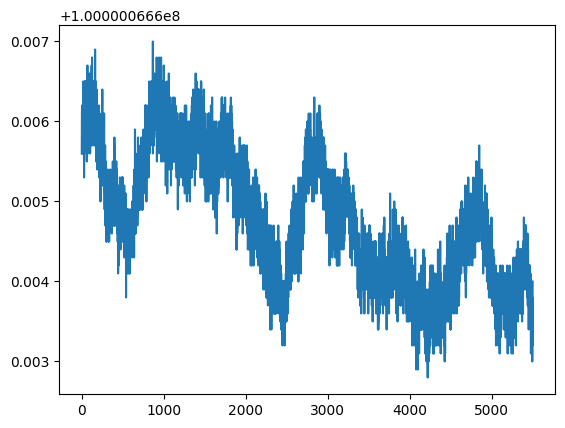

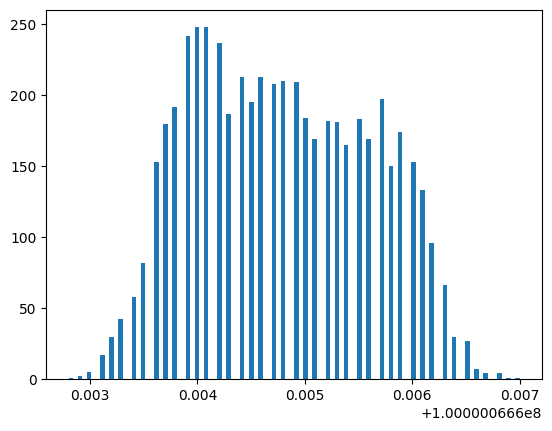

Standard deviation: 0.000821309462671648 Hz
Mean: 100000066.58478539


In [22]:
datafile = Path('/home/mike/Documents/Boulder_PhD/Data/11-24-25/counter2.txt')
df = pd.read_csv(datafile, delimiter='\t')
time_axis = df['Time (s)']
frequencies = df['Frequency (Hz)']

# remove unlock point
frequencies = frequencies[time_axis < 5500]
time_axis = time_axis[time_axis < 5500]

# w/ outliers
plt.plot(time_axis, frequencies)
plt.show()

plt.hist(frequencies, bins=100)
# plt.hist(freqs_no_outliers, bins=100)
plt.show()
print(f'Standard deviation: {np.std(frequencies)} Hz')
print(f'Mean: {np.mean(frequencies)}')

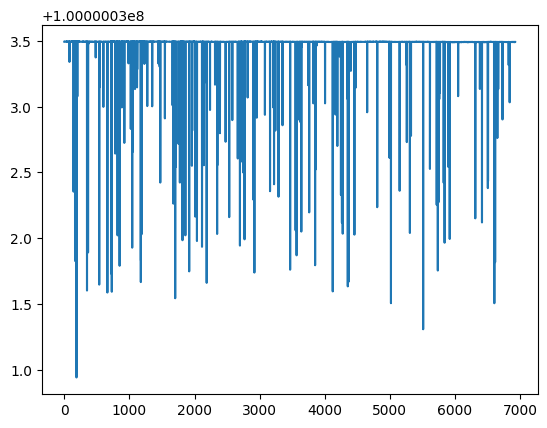

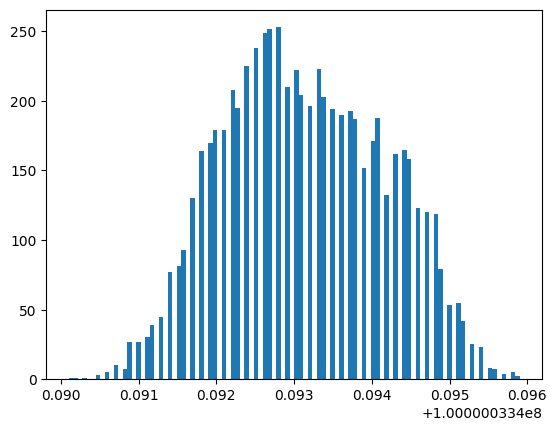

Standard deviation: 0.0010309222249324907 Hz
Mean: 100000033.49312878


In [23]:
datafile = Path('/home/mike/Documents/Boulder_PhD/Data/11-24-25/counter1.txt')
df = pd.read_csv(datafile, delimiter='\t')
time_axis = df['Time (s)']
frequencies = df['Frequency (Hz)']

freqs_no_outliers = remove_outliers(frequencies, .05)

# w/ outliers
plt.plot(time_axis, frequencies)
plt.show()

# plt.hist(frequencies, bins=10000)
plt.hist(freqs_no_outliers, bins=100)
plt.show()
print(f'Standard deviation: {np.std(freqs_no_outliers)} Hz')
print(f'Mean: {np.mean(freqs_no_outliers)}')